<a href="https://colab.research.google.com/github/Parthwadekar40/Parth40-MachineVision/blob/main/Prac2_MV_Parth40.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Please select and upload your product inspection image:


Saving assortment-abstract-3d-design-elements_23-2148996835.avif to assortment-abstract-3d-design-elements_23-2148996835.avif
Calibration Successful! Scale: 19.68 pixels/mm


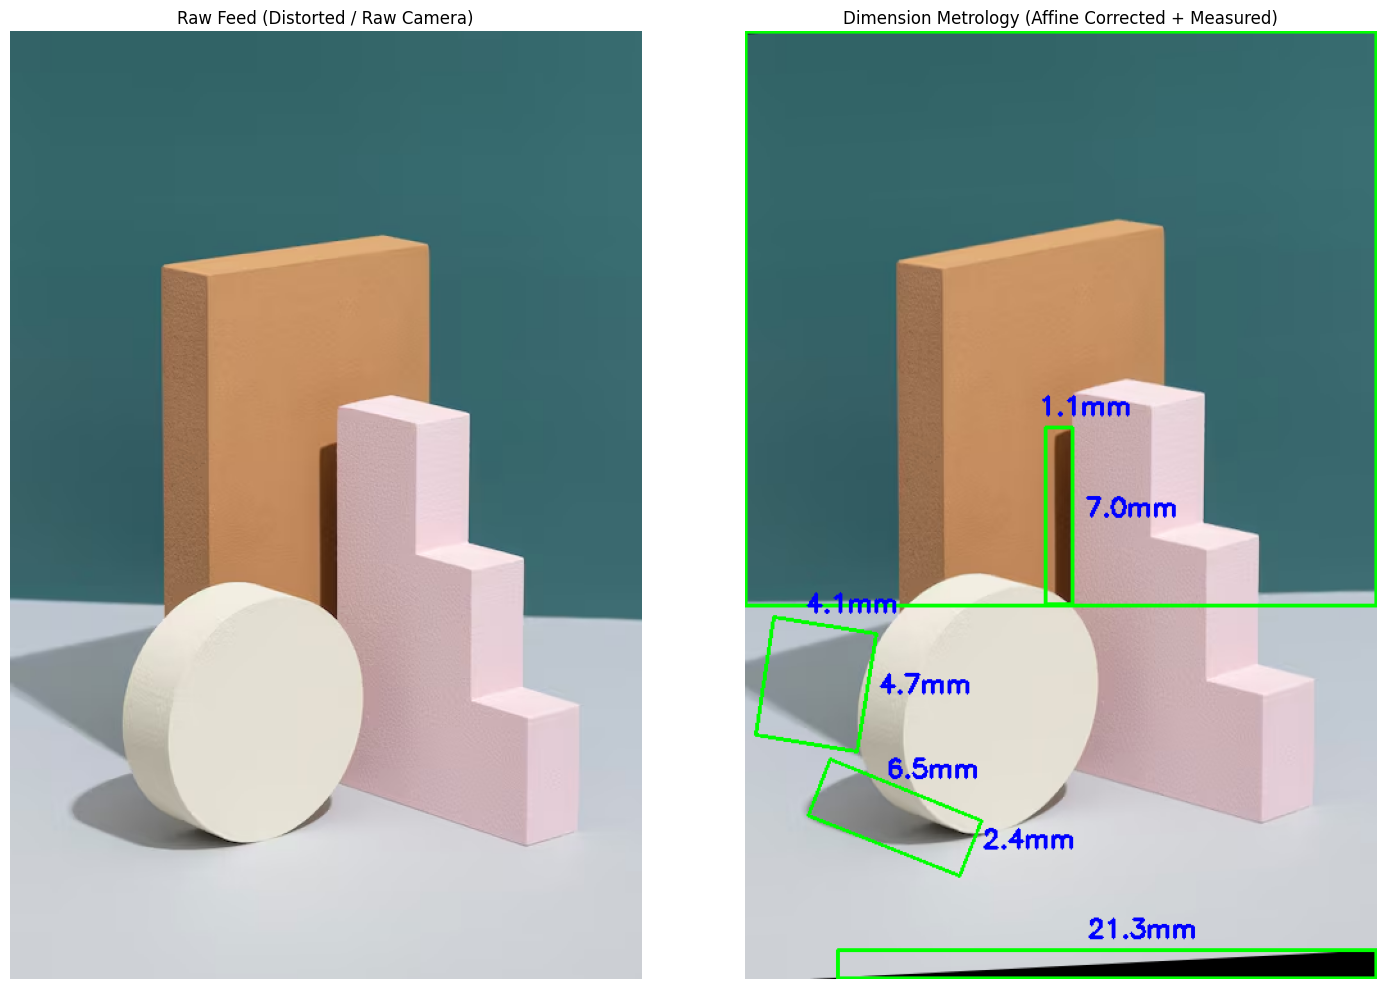

In [1]:
import io
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from scipy.spatial import distance as dist

def order_points(pts):
    # Sort coordinates: top-left, top-right, bottom-right, bottom-left
    x_sorted = pts[np.argsort(pts[:, 0]), :]
    left_most = x_sorted[:2, :]
    right_most = x_sorted[2:, :]

    left_most = left_most[np.argsort(left_most[:, 1]), :]
    (tl, bl) = left_most

    right_most = right_most[np.argsort(right_most[:, 1]), :]
    (tr, br) = right_most

    return np.array([tl, tr, br, bl], dtype="float32")

def midpoint(ptA, ptB):
    return ((ptA[0] + ptB[0]) * 0.5, (ptA[1] + ptB[1]) * 0.5)

# --- Configuration for Metrology ---
# We assume a known reference object (e.g., the leftmost detected item) has a width of 25.0 mm
REFERENCE_WIDTH_MM = 25.0

print("Please select and upload your product inspection image:")
uploaded = files.upload()

if uploaded:
    file_name = list(uploaded.keys())[0]
    image_bytes = uploaded[file_name]

    # 1. Load Image
    nparr = np.frombuffer(image_bytes, np.uint8)
    img = cv2.imdecode(nparr, cv2.IMREAD_COLOR)
    h, w = img.shape[:2]

    # 2. Apply Affine Transformation to correct camera angle tilt
    # Map 3 points from tilted camera view to a flat orthogonal plane
    pts_src = np.float32([[50, 50], [w - 50, 70], [50, h - 50]])  # Simulated tilted points
    pts_dst = np.float32([[50, 50], [w - 50, 50], [50, h - 50]])  # Target flat points

    affine_matrix = cv2.getAffineTransform(pts_src, pts_dst)
    corrected_img = cv2.warpAffine(img, affine_matrix, (w, h))

    # 3. Image Pre-processing for Object Detection
    gray = cv2.cvtColor(corrected_img, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (7, 7), 0)

    # Thresholding to extract object silhouettes
    _, thresh = cv2.threshold(blurred, 50, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # Clean up minor noise with morphology
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
    closed = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)

    # 4. Find Contours
    contours, _ = cv2.findContours(closed.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Sort contours from left-to-right (the leftmost contour is assumed to be our reference object)
    boundingBoxes = [cv2.boundingRect(c) for c in contours]
    (contours, _) = zip(*sorted(zip(contours, boundingBoxes), key=lambda b: b[1][0]))

    pixels_per_metric = None
    output_img = corrected_img.copy()

    for c in contours:
        # Ignore tiny speckles/noise contours
        if cv2.contourArea(c) < 500:
            continue

        # Compute rotated bounding box (handles object rotation on conveyor)
        box = cv2.minAreaRect(c)
        box = cv2.boxPoints(box)
        box = np.array(box, dtype="int")

        # Order the points cleanly
        box = order_points(box)

        # Draw the contours
        cv2.drawContours(output_img, [box.astype("int")], -1, (0, 255, 0), 2)

        # Unpack corner coordinates
        (tl, tr, br, bl) = box

        # Calculate midpoints between parallel edges
        (tltrX, tltrY) = midpoint(tl, tr)
        (blbrX, blbrY) = midpoint(bl, br)
        (tlblX, tlblY) = midpoint(tl, bl)
        (trbrX, trbrY) = midpoint(tr, br)

        # Calculate pixel distances (Euclidean metric)
        dimA_px = dist.euclidean((tltrX, tltrY), (blbrX, blbrY)) # Height
        dimB_px = dist.euclidean((tlblX, tlblY), (trbrX, trbrY)) # Width

        # 5. Calibrate using the Leftmost Reference Object
        if pixels_per_metric is None:
            # Calibrate based on the assumption that the first object's width equals REFERENCE_WIDTH_MM
            pixels_per_metric = dimB_px / REFERENCE_WIDTH_MM
            print(f"Calibration Successful! Scale: {pixels_per_metric:.2f} pixels/mm")

        # Convert dimensions from pixels to millimeters
        dimA_mm = dimA_px / pixels_per_metric
        dimB_mm = dimB_px / pixels_per_metric

        # Draw measurement dimensions on the output image
        cv2.putText(output_img, f"{dimB_mm:.1f}mm", (int(tltrX) - 15, int(tltrY) - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.65, (255, 0, 0), 2)
        cv2.putText(output_img, f"{dimA_mm:.1f}mm", (int(trbrX) + 10, int(trbrY)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.65, (255, 0, 0), 2)

    # Display comparison plots
    plt.figure(figsize=(15, 10))

    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title("Raw Feed (Distorted / Raw Camera)")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(cv2.cvtColor(output_img, cv2.COLOR_BGR2RGB))
    plt.title("Dimension Metrology (Affine Corrected + Measured)")
    plt.axis('off')

    plt.tight_layout()
    plt.show()

else:
    print("No image uploaded.")